--- Generating Active Household Count Evolution (Verified Columns) ---


Success! The chart now uses NN_MORADORES_ANALISE correctly.


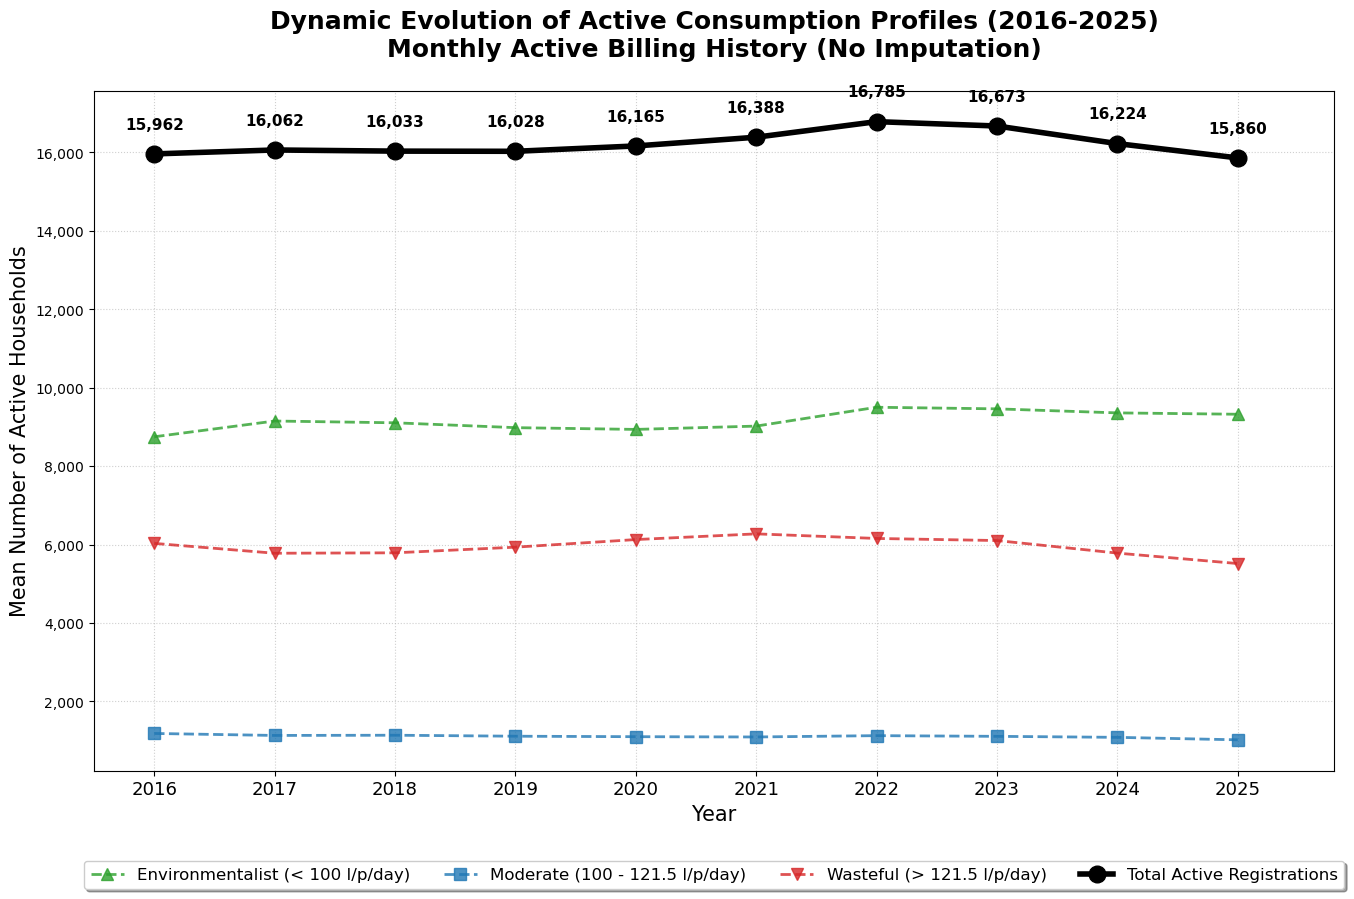

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ==========================================
# 1. Configurations and Paths
# ==========================================
BASE_PATH = '..' 

# Input Filenames
BASELINE_FILE = 'Tabela_consumidores_Itapua_com_setor_comportamento_e_renda_2015.csv'
HISTORY_120M = 'Tabela_consumo_Itapua_120m.csv'

# Output ConfigurationTabela_consumidores_Itapua_com_setor_comportamento_e_renda_2015.csv
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-household-count-evolution-active-2016-2025-en.pdf'
INPUT_DIR_INCLUDES = os.path.join(BASE_PATH, 'includes')

def classify_profile(daily_liters):
    """ Classifies behavior based on liters per person per day """
    if daily_liters < 100.0:
        return 'ENVIRONMENTALIST'
    elif daily_liters <= 121.5:
        return 'MODERATE'
    else:
        return 'WASTEFUL'

def main():
    print("--- Generating Active Household Count Evolution (Verified Columns) ---")

    # ==========================================
    # 2. Data Loading
    # ==========================================
    
    # A. Load Residents metadata (Fixed baseline from our previous step)
    path_baseline = os.path.join(INPUT_DIR_INCLUDES, BASELINE_FILE)
    df_residents = pd.read_csv(path_baseline, sep=';')
    # Using the specific analysis column we created in the baseline script
    df_residents = df_residents[['SK_MATRICULA', 'NN_MORADORES_ANALISE']]
    
    # B. Load Consumption History (The active records driver)
    path_120m = os.path.join(INPUT_DIR_INCLUDES, 'dados', HISTORY_120M)
    df_120m = pd.read_csv(path_120m, sep=';')
    df_120m['AM_REFERENCIA'] = df_120m['AM_REFERENCIA'].astype(int)
    
    # Filter for the validation period (2016-2025)
    df_120m = df_120m[(df_120m['AM_REFERENCIA'] >= 201601) & (df_120m['AM_REFERENCIA'] <= 202512)]

    # ==========================================
    # 3. Dynamic Processing (Actual Billing Only)
    # ==========================================
    
    # Inner join: Only keeps households that are ACTIVE in that month 
    # AND exist in our master resident list
    df_active = pd.merge(df_120m, df_residents, on='SK_MATRICULA', how='inner')
    
    # Calculate daily liters per capita using the verified residents column
    # Formula: (Consumption in m3 * 1000 liters) / Residents / Average days in month
    df_active['L_P_DAY'] = (df_active['HCLQTCON'] * 1000 / df_active['NN_MORADORES_ANALISE']) / 30.5
    
    # Classify and extract Year
    df_active['DYNAMIC_PROFILE'] = df_active['L_P_DAY'].apply(classify_profile)
    df_active['Year'] = (df_active['AM_REFERENCIA'] // 100).astype(int)

    # ==========================================
    # 4. Aggregation
    # ==========================================
    # Count unique active registrations per month and profile
    monthly_counts = df_active.groupby(['Year', 'AM_REFERENCIA', 'DYNAMIC_PROFILE']).size().unstack(fill_value=0)
    
    # Total active households in each month
    monthly_counts['TOTAL'] = monthly_counts.sum(axis=1)

    # Annual Average of these active counts
    annual_mean_counts = monthly_counts.groupby('Year').mean().reset_index()

    # ==========================================
    # 5. Plotting
    # ==========================================
    fig, ax = plt.subplots(figsize=(16, 10))

    profile_styles = {
        'ENVIRONMENTALIST': {'color': '#2ca02c', 'label': 'Environmentalist (< 100 l/p/day)', 'marker': '^'},
        'MODERATE': {'color': '#1f77b4', 'label': 'Moderate (100 - 121.5 l/p/day)', 'marker': 's'},
        'WASTEFUL': {'color': '#d62728', 'label': 'Wasteful (> 121.5 l/p/day)', 'marker': 'v'}
    }

    # Plot lines for each profile
    for p in ['ENVIRONMENTALIST', 'MODERATE', 'WASTEFUL']:
        if p in annual_mean_counts.columns:
            ax.plot(annual_mean_counts['Year'], annual_mean_counts[p], 
                    label=profile_styles[p]['label'], color=profile_styles[p]['color'],
                    linestyle='--', linewidth=2.0, marker=profile_styles[p]['marker'], markersize=9, alpha=0.8)

    # Plot Total Active Households line
    ax.plot(annual_mean_counts['Year'], annual_mean_counts['TOTAL'], 
            label='Total Active Registrations', color='black',
            linestyle='-', linewidth=4.0, marker='o', markersize=12, zorder=30)

    # Value annotations on the Total line
    for x, y in zip(annual_mean_counts['Year'], annual_mean_counts['TOTAL']):
        ax.annotate(f"{y:,.0f}", (x, y), xytext=(0, 18), textcoords="offset points",
                    ha='center', fontsize=11, fontweight='bold', color='black')

    # General Chart Formatting
    ax.set_ylabel('Mean Number of Active Households', fontsize=15)
    ax.set_xlabel('Year', fontsize=15)
    years = annual_mean_counts['Year'].tolist()
    ax.set_xticks(years)
    ax.set_xticklabels(years, fontsize=13)
    plt.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(years[0]-0.5, years[-1]+0.8)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

    plt.title('Dynamic Evolution of Active Consumption Profiles (2016-2025)\n'
              'Monthly Active Billing History (No Imputation)', fontsize=18, fontweight='bold', pad=25)

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=12, frameon=True, shadow=True)
    plt.subplots_adjust(bottom=0.20)

    # Save
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    print(f"Success! The chart now uses NN_MORADORES_ANALISE correctly.")
    plt.show()

if __name__ == "__main__":
    main()